<a href="https://colab.research.google.com/github/minhaz-engg/Time-Series-try/blob/main/neuralforecast_supply_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install mlforecast

In [5]:
import pandas as pd
import lightgbm as lgb
from xgboost import XGBRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mse, mae, mape
import matplotlib.pyplot as plt
import seaborn as sns
from utilsforecast.plotting import plot_series

In [6]:
# ==============================================================================
# 1. INGESTING EMPIRICAL SUPPLY CHAIN TELEMETRY
# ==============================================================================
print("Ingesting live empirical supply chain data (Avocado Retail Volume)...")

# Utilizing a highly stable, verified GitHub repository for the empirical dataset
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/avocado.csv"
df_raw = pd.read_csv(url)

# The raw dataset contains an extraneous index column ('Unnamed: 0') which we must ablate
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])

Ingesting live empirical supply chain data (Avocado Retail Volume)...


In [7]:
# To maintain temporal continuity and mitigate cross-sectional noise for this demonstration,
# we isolate a specific operational macro-region ('TotalUS') and product tier ('conventional').
df_filtered = df_raw[(df_raw['region'] == 'TotalUS') & (df_raw['type'] == 'conventional')].copy()

# Reformatting to adhere to the Nixtlaverse structural paradigm (unique_id, ds, y)
# 'Total Volume' represents our core target: Consumer Demand.
df = df_filtered.rename(columns={'Date': 'ds', 'Total Volume': 'y'})
df['unique_id'] = 'SupplyChain_TotalUS_Conventional'
df['ds'] = pd.to_datetime(df['ds'])

# Ensuring chronological integrity is paramount in time-series operations
df = df.sort_values('ds').reset_index(drop=True)

# Isolating our target and our exogenous logistical/economic drivers
exogenous_features = ['AveragePrice', 'Total Bags', 'Small Bags', 'Large Bags']
df = df[['unique_id', 'ds', 'y'] + exogenous_features]

In [8]:
# ==============================================================================
# 2. ARCHITECTING THE MULTIVARIATE FORECAST PARADIGM
# ==============================================================================
print("Architecting the algorithmic paradigm...")

models = [
    lgb.LGBMRegressor(random_state=42, verbosity=-1, n_estimators=150, learning_rate=0.05),
    XGBRegressor(random_state=42, n_estimators=150, learning_rate=0.05, objective='reg:squarederror')
]

forecast_engine = MLForecast(
    models=models,
    freq='W', # This empirical dataset is recorded at a Weekly frequency
    lags=[1, 4, 12, 52], # Capturing 1-week, 1-month, 1-quarter, and 1-year autoregressive cycles
    lag_transforms={
        4: [RollingMean(window_size=4)],
        12: [RollingMean(window_size=12)]
    },
    date_features=['month', 'quarter'],
    target_transforms=[Differences([1])] # Enforcing stationarity to mitigate secular trend bias
)

Architecting the algorithmic paradigm...


In [9]:
# ==============================================================================
# 3. STRICT TEMPORAL VALIDATION PARTITIONING
# ==============================================================================
horizon = 12 # Projecting the subsequent 12 weeks (roughly one fiscal quarter)
df_train = df.iloc[:-horizon]
df_test = df.iloc[-horizon:]

# Isolating the future values of our exogenous covariates.
# In a live production environment, these vectors (like planned Price) are supplied by the business.
X_df = df_test[['unique_id', 'ds'] + exogenous_features]

In [10]:
# ==============================================================================
# 4. ALGORITHMIC OPTIMIZATION AND INFERENCE
# ==============================================================================
print("Commencing model fitting on empirical supply chain data...")
forecast_engine.fit(
    df_train,
    id_col='unique_id',
    time_col='ds',
    target_col='y',
    static_features=[]
)

print("Executing multivariate projection for the upcoming quarter...")
predictions = forecast_engine.predict(h=horizon, X_df=X_df)

Commencing model fitting on empirical supply chain data...
Executing multivariate projection for the upcoming quarter...


In [11]:
# ==============================================================================
# 5. QUANTIFICATION OF VERACITY
# ==============================================================================
results = predictions.merge(df_test[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'])

evaluation_metrics = evaluate(
    df=results,
    metrics=[mse, mae, mape],
    models=['LGBMRegressor', 'XGBRegressor']
)

print("\nEmpirical Supply Chain Evaluation Metrics:")
print(evaluation_metrics.groupby('metric').mean(numeric_only=True))


Empirical Supply Chain Evaluation Metrics:
        LGBMRegressor  XGBRegressor
metric                             
mae      1.415808e+07  5.437412e+06
mape     3.394796e-01  1.240914e-01
mse      3.092087e+14  4.622137e+13



Initiating advanced visual diagnostics...


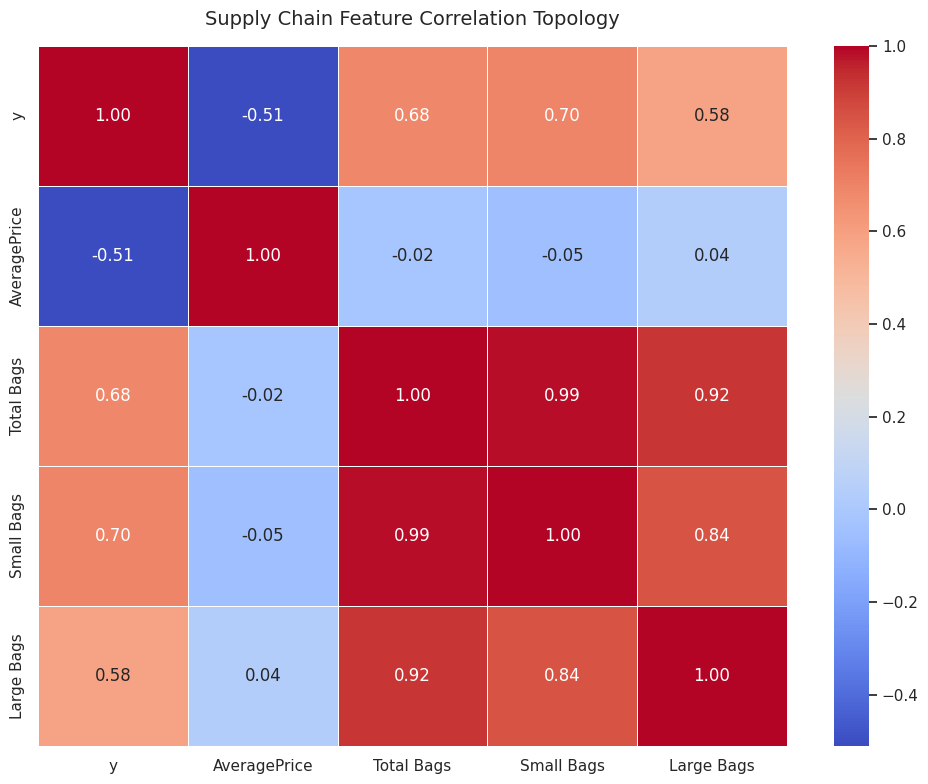

In [12]:
print("\nInitiating advanced visual diagnostics...")
sns.set_theme(style="whitegrid", palette="muted")

# --- Visualization A: Multivariate Correlation Topology ---
plt.figure(figsize=(10, 8))
# Computing Pearson correlation to elucidate the inverse relationship between Price and Volume
correlation_matrix = df[['y'] + exogenous_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Supply Chain Feature Correlation Topology', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('sc_diagnostic_1_correlation.png', dpi=300)
plt.show()

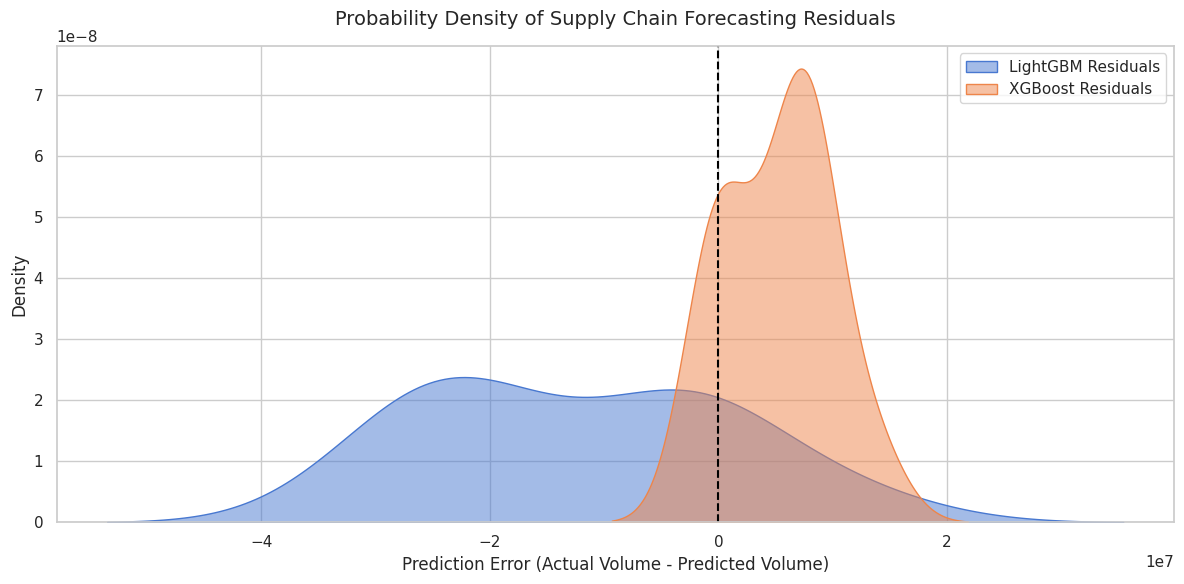

In [13]:
# --- Visualization B: High-Fidelity Forecast Trajectory (Nixtla Native) ---
# Isolating the most recent year of history to prevent visual obfuscation
historical_context = df_train.tail(52)
fig_trajectory = plot_series(
    df=historical_context,
    forecasts_df=predictions,
    models=['LGBMRegressor', 'XGBRegressor'],
    palette='Set1'
)
fig_trajectory.savefig('sc_diagnostic_2_forecast_trajectory.png', dpi=300, bbox_inches='tight')

# --- Visualization C: Algorithmic Residual Distribution ---
plt.figure(figsize=(12, 6))
results_copy = results.copy()
results_copy['LGBM_Residuals'] = results_copy['y'] - results_copy['LGBMRegressor']
results_copy['XGB_Residuals'] = results_copy['y'] - results_copy['XGBRegressor']

sns.kdeplot(data=results_copy['LGBM_Residuals'], label='LightGBM Residuals', fill=True, alpha=0.5)
sns.kdeplot(data=results_copy['XGB_Residuals'], label='XGBoost Residuals', fill=True, alpha=0.5)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Probability Density of Supply Chain Forecasting Residuals', fontsize=14, pad=15)
plt.xlabel('Prediction Error (Actual Volume - Predicted Volume)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('sc_diagnostic_3_residuals.png', dpi=300)
plt.show()

/tmp/ipykernel_10321/2559363373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


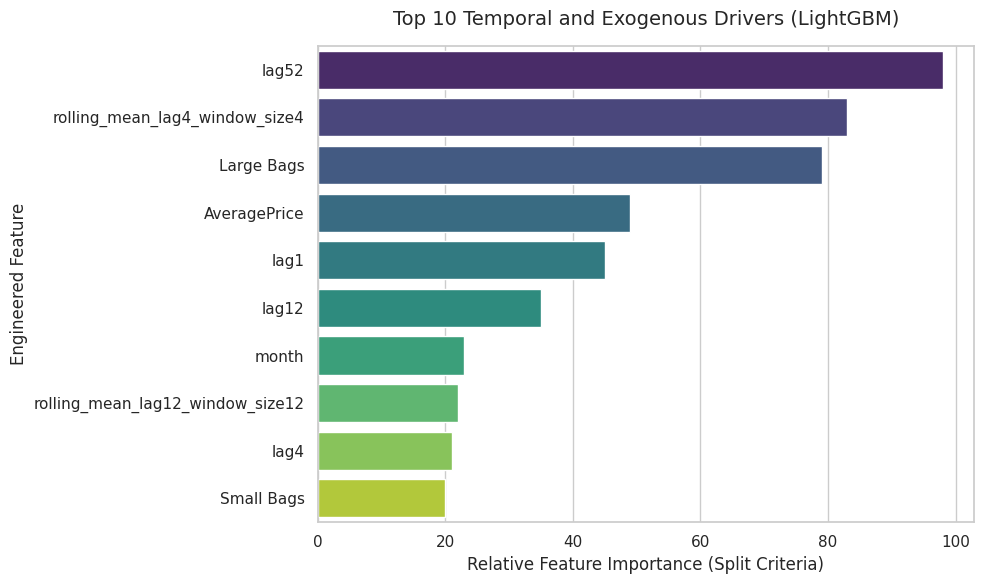

In [14]:
# --- Visualization D: Gradient Boosting Feature Importance ---
plt.figure(figsize=(10, 6))
lgbm_model = forecast_engine.models_['LGBMRegressor']
importance_df = pd.DataFrame({
    'Feature': forecast_engine.ts.features_order_,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Temporal and Exogenous Drivers (LightGBM)', fontsize=14, pad=15)
plt.xlabel('Relative Feature Importance (Split Criteria)')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.savefig('sc_diagnostic_4_feature_importance.png', dpi=300)
plt.show()

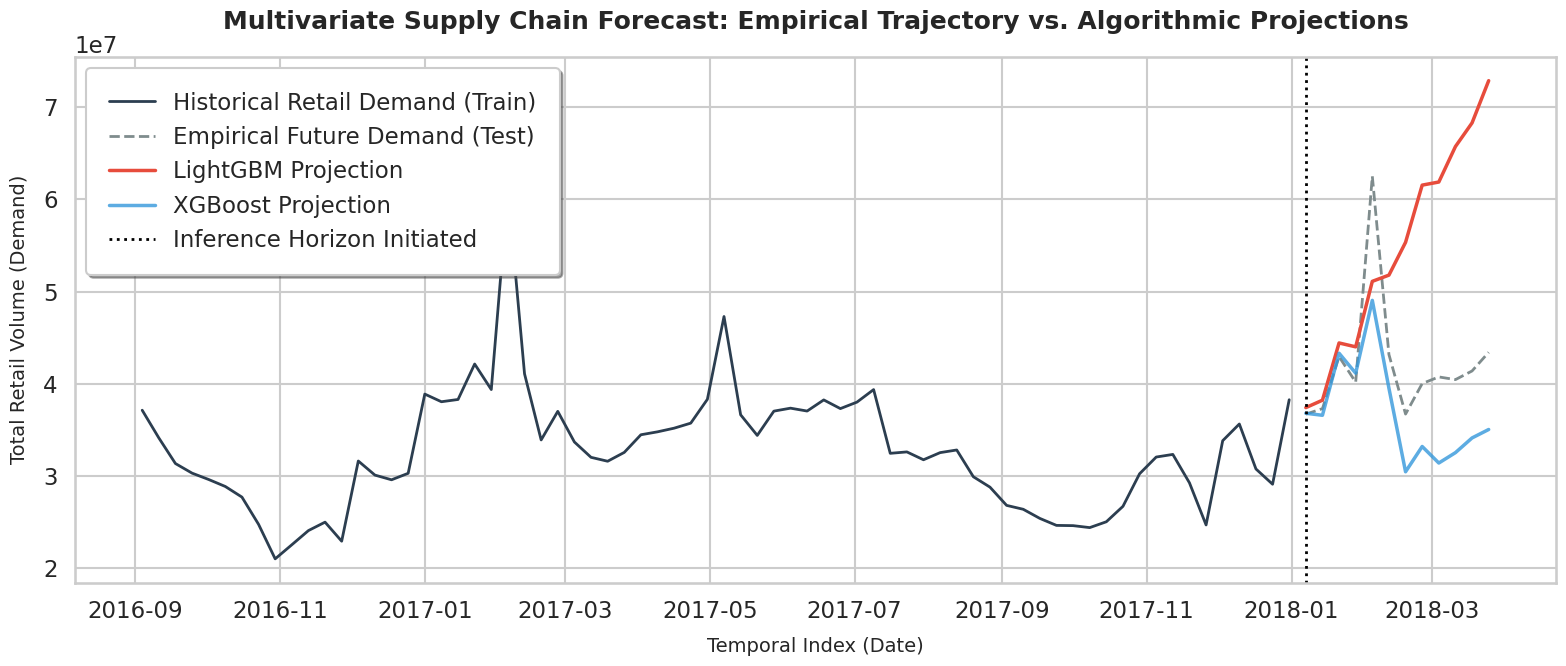

In [16]:
# --- Visualization E: Bespoke Time-Series Line Plot ---
plt.figure(figsize=(16, 7))
sns.set_theme(style="whitegrid", context="talk")
history_window = df_train.tail(70)

plt.plot(history_window['ds'], history_window['y'], label='Historical Retail Demand (Train)', color='#2c3e50', linewidth=2)
plt.plot(df_test['ds'], df_test['y'], label='Empirical Future Demand (Test)', color='#7f8c8d', linewidth=2, linestyle='--')
plt.plot(predictions['ds'], predictions['LGBMRegressor'], label='LightGBM Projection', color='#e74c3c', linewidth=2.5)
plt.plot(predictions['ds'], predictions['XGBRegressor'], label='XGBoost Projection', color='#3498db', linewidth=2.5, alpha=0.8)

plt.title('Multivariate Supply Chain Forecast: Empirical Trajectory vs. Algorithmic Projections', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Temporal Index (Date)', fontsize=14, labelpad=10)
plt.ylabel('Total Retail Volume (Demand)', fontsize=14, labelpad=10)

forecast_start = df_test['ds'].iloc[0]
plt.axvline(x=forecast_start, color='black', linestyle=':', linewidth=2, label='Inference Horizon Initiated')
plt.legend(loc='upper left', frameon=True, shadow=True, borderpad=1)
plt.tight_layout()
plt.savefig('sc_diagnostic_5_bespoke_timeseries.png', dpi=300)
plt.show()